In [1]:
import polars as pl
import os

import sys

sys.path.append("..")
from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()
import numpy as np
import json
from skimage.measure import label

from skimage import measure

from src import IOFunctions

IO = IOFunctions.IO_Functions()

import matplotlib.pyplot as plt

from src import AnalysisFunctions

A_F = AnalysisFunctions.Analysis_Functions()

from src import CoincidenceFunctions

C_F = CoincidenceFunctions.Coincidence_Functions()

In [2]:
cingulate_PD_region = (
    "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots"
)

In [3]:
files = os.listdir(cingulate_PD_region)
files = np.sort([x for x in files if ".csv" in x])
files = np.sort([x for x in files if "images_" in x])

In [4]:
files

array(['images_C030_HC.csv', 'images_C043_HC.csv', 'images_C074_HC.csv',
       'images_PD0086_PD.csv', 'images_PD0612_PD.csv',
       'images_PD0913_PD.csv', 'images_PD0917_PD.csv',
       'images_PD0945_PD.csv'], dtype='<U20')

In [5]:
PD_patients = ["PD0086", "PD0945", "PD0612", "PD0913", "PD0917"]
HC_patients = ["C030", "C064", "C036", "C043", "C049", "C074"]

In [6]:
def file_selector(folder, oligomer_data, percentile=20):
    files = os.listdir(folder)
    file = np.sort(
        [
            x
            for x in files
            if "percentile" in x
            and "_" + str(int(percentile)) + "_" in x
            and "3Danalysis" in x
        ]
    )[0]
    data = pl.read_csv(os.path.join(folder, file))
    photonthreshold = float(
        file.split("_photonthreshold_")[1].split("_photons_")[0].replace("p", ".")
    )
    oligomer_data = oligomer_data.filter(pl.col("sum_intensity_in_photons") < 3000)
    percentile = oligomer_data["sum_intensity_in_photons"].rank() / len(
        oligomer_data["sum_intensity_in_photons"]
    )
    oligomer_data = oligomer_data.with_columns(percentile.alias("alpha"))
    return oligomer_data

In [7]:
raw_data_region = "/scratch/sycamore-asap/ASAP_Imaging_Data/Main_Survey/20241105_oligomers_in_cells/cingulate/neurons/PD_analysis"
cingulate_PD_data = pl.read_csv(os.path.join(raw_data_region, "spot_analysis.csv"))
cingulate_PD_data = file_selector(raw_data_region, cingulate_PD_data, percentile=90)

In [8]:
filenames = np.unique(cingulate_PD_data["image_filename"].to_numpy())

In [9]:
PD1_neuron_files = pl.read_csv(os.path.join(cingulate_PD_region, files[3]))
PD1_neuron_files = PD1_neuron_files.filter(pl.col("cell_type") == "neurons").filter(
    pl.col("region") == "cingulate"
)

In [10]:
specific_files = [
    x.split("\\")[-1].split(".tif")[0]
    for x in np.unique(PD1_neuron_files["image_filename"])
    if ".tif" in x
]
filenames = []
for fname in specific_files:
    filenames = np.hstack(
        [
            filenames,
            np.unique(
                [
                    x
                    for x in cingulate_PD_data["image_filename"].to_numpy()
                    if fname in x
                ]
            ),
        ]
    )

In [11]:
def quick_plotter(
    filename,
    oligomer_data=None,
    protein_string="C1",
    cell_string="C0",
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    zplane=None,
    labelval=None,
    alpha_threshold=0.0,
    show_oligomers=False,
    scalebarsize=10000,
    scalebarlabel="10 µm",
):
    """
    Plot cell mask with optional oligomer overlay and return oligomers inside selected cell.

    Parameters:
    -----------
    filename : str
        Path to the protein image file
    oligomer_data : polars.DataFrame, optional
        DataFrame containing oligomer data with columns: image_filename, x, y, alpha, zi, zf
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for plotting
    zplane : int, optional
        Specific z-plane to show for protein (if None, uses MIP)
    labelval : int, optional
        Specific label value to plot. If None, plots all labels separately
    alpha_threshold : float
        Minimum alpha value for oligomer filtering (default 0.0)
    show_oligomers : bool
        Whether to overlay oligomer positions on the plot (default False)

    Returns:
    --------
    oligomers_in_cell : polars.DataFrame or None
        Filtered oligomers inside the selected label (only when labelval is specified and oligomer_data provided)
    """
    raw_protein_image = IO.read_tiff_tophotons(filename)
    analysis_folder = os.path.split(os.path.split(filename)[0])[0] + "_analysis"

    cell_filename = filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)
    cell_MIP = np.max(raw_cell_image, axis=0)

    if zplane is not None:
        protein_MIP = raw_protein_image[zplane, :, :]
    else:
        protein_MIP = np.max(raw_protein_image, axis=0)

    cell_mask_string = (
        os.path.split(filename)[-1].split(protein_string + ".tif")[0]
        + cell_string
        + "_cellMask_cleanedup.tiff"
    )
    cell_mask = IO.read_tiff(os.path.join(analysis_folder, cell_mask_string))
    labeled_image = label(cell_mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)

    oligomers_in_cell = None

    if labelval is not None:
        fig, axs = plotter.one_column_plot()
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1

        # Filter oligomers if data provided
        if oligomer_data is not None:
            # Get oligomers for this image
            oligomers = oligomer_data.filter(pl.col("image_filename") == filename)
            oligomers = oligomers.filter(pl.col("alpha") >= alpha_threshold)

            if len(oligomers) > 0:
                x = oligomers["x"].to_numpy()
                y = oligomers["y"].to_numpy()
                alpha = oligomers["alpha"].to_numpy()

                # Generate indices for mask and spots
                centroids = np.vstack(
                    [np.array(x, dtype=int), np.array(y, dtype=int)]
                ).T
                mask_indices = A_F.generate_indices(
                    np.array(mask_toplot_filtered, dtype=bool),
                    (1200, 1200),
                    is_mask=True,
                )
                spot_indices = A_F.generate_indices(centroids, (1200, 1200))
                spot_indices = C_F._apply_blur(spot_indices, (1200, 1200), 1)

                # Test which oligomers are inside the cell
                in_cell = C_F.test_spot_spot_overlap(
                    spot_indices, mask_indices, n_spot1=len(x), raw=True
                )

                # Filter oligomers
                oligomers_in_cell = oligomers.filter(pl.lit(in_cell))

                print(
                    f"Found {len(oligomers_in_cell)} oligomers inside cell label {labelval}"
                )
                print(f"  Total oligomers in image: {len(oligomers)}")
                print(
                    f"  Percentage in cell: {100*len(oligomers_in_cell)/len(oligomers):.2f}%"
                )

                # Optionally show oligomers on plot
                if show_oligomers and len(oligomers_in_cell) > 0:
                    x_in = oligomers_in_cell["x"].to_numpy()
                    y_in = oligomers_in_cell["y"].to_numpy()
                    alpha_in = oligomers_in_cell["alpha"].to_numpy()

                    # Filter to plotting region
                    plot_indices = (
                        (x_in >= xmin) & (x_in < xmax) & (y_in >= ymin) & (y_in < ymax)
                    )
                    x_plot = x_in[plot_indices] - xmin
                    y_plot = y_in[plot_indices] - ymin
                    alpha_plot = alpha_in[plot_indices]

                    axs[0] = plotter.image_scatter_plot(
                        axs=axs[0],
                        data=protein_MIP[xmin:xmax, ymin:ymax],
                        xdata=x_plot,
                        ydata=y_plot,
                        facecolor="red",
                        alpha_scatter=alpha_plot,
                        s=10,
                        lws=0,
                        cbar="off",
                        scalebarsize=scalebarsize,
                        scalebarlabel=scalebarlabel,
                    )
                    axs[0].contour(
                        mask_toplot_filtered[xmin:xmax, ymin:ymax],
                        [0.5],
                        lw=0.75,
                        colors="white",
                    )
                else:
                    axs[0] = plotter.image_plot(
                        axs=axs[0],
                        data=protein_MIP[xmin:xmax, ymin:ymax],
                        cbar="off",
                        scalebarsize=scalebarsize,
                        scalebarlabel=scalebarlabel,
                    )
                    axs[0].contour(
                        mask_toplot_filtered[xmin:xmax, ymin:ymax],
                        [0.5],
                        lw=0.75,
                        colors="white",
                    )
            else:
                print(f"No oligomers found in image with alpha >= {alpha_threshold}")
                axs[0] = plotter.image_plot(
                    axs=axs[0],
                    data=protein_MIP[xmin:xmax, ymin:ymax],
                    cbar="off",
                    scalebarsize=scalebarsize,
                    scalebarlabel=scalebarlabel,
                )
                axs[0].contour(
                    mask_toplot_filtered[xmin:xmax, ymin:ymax],
                    [0.5],
                    lw=0.75,
                    colors="white",
                )
        else:
            # No oligomer data provided, just plot the mask
            axs[0] = plotter.image_plot(
                axs=axs[0],
                data=protein_MIP[xmin:xmax, ymin:ymax],
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel=scalebarlabel,
            )
            axs[0].contour(
                mask_toplot_filtered[xmin:xmax, ymin:ymax],
                [0.5],
                lw=0.75,
                colors="white",
            )

    else:
        # Plot all labels separately (original behavior)
        for value in np.arange(len(np.unique(mask_toplot))):
            fig, axs = plotter.one_column_plot()
            mask_toplot_filtered = mask_toplot.copy()
            mask_toplot_filtered[mask_toplot_filtered != value] = 0
            mask_toplot_filtered[mask_toplot_filtered == value] = 1
            axs[0] = plotter.image_plot(
                axs=axs[0],
                data=protein_MIP[xmin:xmax, ymin:ymax],
                cbar="off",
                scalebarsize=scalebarsize,
                scalebarlabel=scalebarlabel,
            )
            axs[0].contour(
                mask_toplot_filtered[xmin:xmax, ymin:ymax],
                [0.5],
                lw=0.75,
                colors="white",
            )

    return fig, axs, oligomers_in_cell

20231010_MS_R1_S36_SS1 - Position 1 [9]_XY1697034408_Z00_T1_C1.tif
Found 17 oligomers inside cell label 5
  Total oligomers in image: 11835
  Percentage in cell: 0.14%


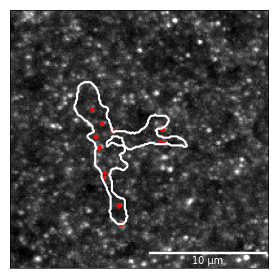


Oligomer data shape: (17, 10)

First few oligomers:
shape: (5, 10)
┌───────┬───────┬─────┬────────────────────────┬───┬─────┬──────┬───────────────────────┬──────────┐
│ y     ┆ x     ┆ z   ┆ sum_intensity_in_photo ┆ … ┆ zi  ┆ zf   ┆ image_filename        ┆ alpha    │
│ ---   ┆ ---   ┆ --- ┆ ns                     ┆   ┆ --- ┆ ---  ┆ ---                   ┆ ---      │
│ f64   ┆ f64   ┆ f64 ┆ ---                    ┆   ┆ f64 ┆ f64  ┆ str                   ┆ f64      │
│       ┆       ┆     ┆ f64                    ┆   ┆     ┆      ┆                       ┆          │
╞═══════╪═══════╪═════╪════════════════════════╪═══╪═════╪══════╪═══════════════════════╪══════════╡
│ 268.0 ┆ 442.0 ┆ 4.0 ┆ 689.777587             ┆ … ┆ 2.0 ┆ 22.0 ┆ /scratch/sycamore-asa ┆ 0.912835 │
│       ┆       ┆     ┆                        ┆   ┆     ┆      ┆ p/ASAP_Im…            ┆          │
│ 273.0 ┆ 423.0 ┆ 5.0 ┆ 789.209521             ┆ … ┆ 2.0 ┆ 22.0 ┆ /scratch/sycamore-asa ┆ 0.94964  │
│       ┆       ┆     ┆

In [12]:
# Example usage of upgraded quick_plotter with oligomer filtering
i = 1
file = filenames[i]
print(os.path.split(file)[-1])

# Call the upgraded function - it now returns the oligomers inside the selected cell
fig, axs, oligomers_in_selected_cell = quick_plotter(
    file,
    oligomer_data=cingulate_PD_data,
    labelval=5,
    xmin=350,
    xmax=550,
    ymin=200,
    ymax=400,
    alpha_threshold=0.9,
    show_oligomers=True,
)

plt.savefig("Neuron_PD_COSMX.svg", dpi=600, format="svg")
plt.show(block=False)
# Now you can access the filtered oligomer data
if oligomers_in_selected_cell is not None:
    print(f"\nOligomer data shape: {oligomers_in_selected_cell.shape}")
    print("\nFirst few oligomers:")
    print(oligomers_in_selected_cell.head())

In [13]:
oligomers_in_selected_cell[11]

y,x,z,sum_intensity_in_photons,bg_per_punctum,bg_per_pixel,zi,zf,image_filename,alpha
f64,f64,f64,f64,f64,f64,f64,f64,str,f64
284.0,397.0,13.0,672.514532,2968.820416,49.48034,2.0,22.0,"""/scratch/sycamore-asap/ASAP_Im…",0.904053


In [14]:
oligomer_zs = np.array([4, 6, 12])
oligomers_xmins = np.array([433, 447, 387])
oligomers_xmaxs = np.array([453, 467, 407])
oligomers_ymins = np.array([259, 308, 274])
oligomers_ymaxs = np.array([279, 328, 294])

In [15]:
xmins = np.array([100, 0, 0])
widths = np.array([300, 325, 900])
ymins = np.array([750, 0, 0])

In [16]:
def cell_oligomer_3panel_generator_rawoligomer(
    file,
    oligomer_data,
    folder_to_save,
    protein_string="C1",
    cell_string="C0",
    xmins=0,
    xmaxs=1200,
    ymins=0,
    ymaxs=1200,
    zvals=22,
):
    mm = 1 / 25.4
    fig, axs = plotter.two_column_plot(
        ncolumns=3, widthratio=[1, 1, 1], height=(170 / 3) * mm, width=180 * mm
    )

    for i in np.arange(3):
        xmin = xmins[i]
        xmax = xmaxs[i]
        ymin = ymins[i]
        ymax = ymaxs[i]
        analysis_folder = os.path.split(os.path.split(file)[0])[0] + "_analysis"

        protein_data = IO.read_tiff_tophotons(file)[zvals[i], :, :]
        if i == 0:
            scalebarlabel = r"300 nm"
            scalebarsize = 300
        else:
            scalebarlabel = r"300 nm"
            scalebarsize = 300
        axs[i] = plotter.image_plot(
            axs=axs[i],
            data=protein_data[xmin:xmax, ymin:ymax],
            cbar="off",
            masklinewidth=0.5,
            scalebarlabel=scalebarlabel,
            scalebarsize=scalebarsize,
        )
    return fig, axs

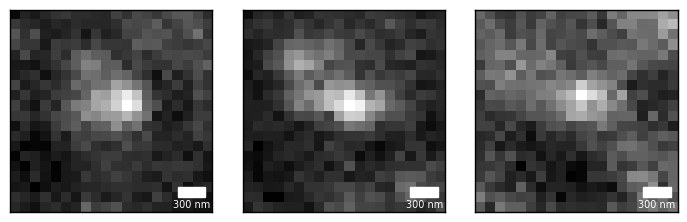

In [17]:
folder_to_save = (
    "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots"
)
fig, axs = cell_oligomer_3panel_generator_rawoligomer(
    file,
    cingulate_PD_data,
    folder_to_save,
    xmins=oligomers_xmins,
    xmaxs=oligomers_xmaxs,
    ymins=oligomers_ymins,
    ymaxs=oligomers_ymaxs,
    zvals=oligomer_zs,
)
plt.tight_layout()
plt.savefig(
    os.path.join(folder_to_save, "Oligomers_in_PD_Neurons.svg"), format="svg", dpi=1200
)

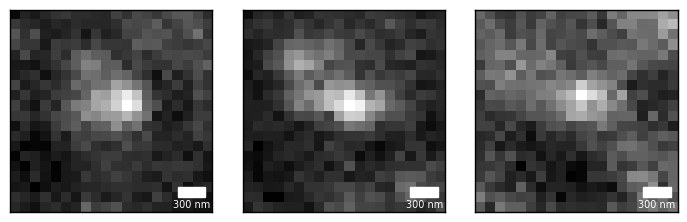

In [18]:
folder_to_save = (
    "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260119_ASAPPlots"
)
fig, axs = cell_oligomer_3panel_generator_rawoligomer(
    file,
    cingulate_PD_data,
    folder_to_save,
    xmins=oligomers_xmins,
    xmaxs=oligomers_xmaxs,
    ymins=oligomers_ymins,
    ymaxs=oligomers_ymaxs,
    zvals=oligomer_zs,
)
plt.tight_layout()
plt.savefig(
    os.path.join(folder_to_save, "Oligomers_in_HC_Neurons.svg"), format="svg", dpi=1200
)


def cell_oligomer_context_panel(
    file,
    oligomer_xmins,
    oligomer_xmaxs,
    oligomer_ymins,
    oligomer_ymaxs,
    labelval=None,
    protein_string="C1",
    cell_string="C0",
    xmin=0,
    xmax=1200,
    ymin=0,
    ymax=1200,
    scalebarsize=10000,
    scalebarlabel="10 µm",
    label_boxes=True,
):
    """
    Create a single context panel showing where all three oligomer visualization regions are located.

    This function shows the same cell zoom as quick_plotter, with white boxes overlaid to indicate
    the three zoomed-in regions shown in oligomer detail panels.

    Parameters:
    -----------
    file : str
        Path to the image file
    oligomer_xmins, oligomer_xmaxs, oligomer_ymins, oligomer_ymaxs : array-like
        Arrays of coordinates defining the zoomed oligomer regions (length 3)
    labelval : int, optional
        Specific cell label to highlight. If None, shows all cells
    protein_string : str
        String identifier for protein channel (default 'C1')
    cell_string : str
        String identifier for cell channel (default 'C0')
    xmin, xmax, ymin, ymax : int
        Crop coordinates for the cell view (same as used in quick_plotter)
    scalebarsize : int
        Size of scale bar in nm (default 10000)
    scalebarlabel : str
        Label for scale bar (default '10 µm')
    label_boxes : bool
        Whether to add numerical labels (1-3) to each box (default True)

    Returns:
    --------
    fig, axs : matplotlib figure and axes
    """
    mm = 1 / 25.4
    fig, axs = plotter.one_column_plot()

    # Load cell mask and images
    analysis_folder = os.path.split(os.path.split(file)[0])[0] + "_analysis"
    cell_filename = file.split(protein_string + ".tif")[0] + cell_string + ".tif"
    raw_cell_image = IO.read_tiff_tophotons(cell_filename)
    cell_MIP = np.max(raw_cell_image, axis=0)

    # Load and label the cell mask
    cell_mask_string = (
        os.path.split(file)[-1].split(protein_string + ".tif")[0]
        + cell_string
        + "_cellMask_cleanedup.tiff"
    )
    cell_mask = IO.read_tiff(os.path.join(analysis_folder, cell_mask_string))
    labeled_image = label(cell_mask, connectivity=3, return_num=False)
    mask_toplot = np.max(labeled_image, axis=0)

    # Filter to specific label if provided
    if labelval is not None:
        mask_toplot_filtered = mask_toplot.copy()
        mask_toplot_filtered[mask_toplot_filtered != labelval] = 0
        mask_toplot_filtered[mask_toplot_filtered == labelval] = 1
    else:
        mask_toplot_filtered = (mask_toplot > 0).astype(int)

    # Plot the cell image with mask contour (same view as quick_plotter)
    axs[0] = plotter.image_plot(
        axs=axs[0],
        data=cell_MIP[xmin:xmax, ymin:ymax],
        cbar="off",
        masklinewidth=0.5,
        scalebarlabel=scalebarlabel,
        scalebarsize=scalebarsize,
    )

    # Add mask contour
    axs[0].contour(
        mask_toplot_filtered[xmin:xmax, ymin:ymax], [0.5], lw=0.75, colors="white"
    )

    # Draw all three white boxes showing oligomer regions
    from matplotlib.patches import Rectangle

    for i in np.arange(3):
        olig_xmin = oligomer_xmins[i]
        olig_xmax = oligomer_xmaxs[i]
        olig_ymin = oligomer_ymins[i]
        olig_ymax = oligomer_ymaxs[i]

        # Convert to coordinates relative to the cropped view
        rect = Rectangle(
            (olig_ymin - ymin, olig_xmin - xmin),
            olig_ymax - olig_ymin,
            olig_xmax - olig_xmin,
            linewidth=2,
            edgecolor="white",
            facecolor="none",
            linestyle="--",
        )
        axs[0].add_patch(rect)

        # Add numerical labels to boxes
        if label_boxes:
            # Position label at top-left corner of box with small offset
            axs[0].text(
                olig_ymin - ymin + 3,
                olig_xmin - xmin + 3,
                str(i + 1),
                color="white",
                fontsize=10,
                weight="bold",
                verticalalignment="top",
                horizontalalignment="left",
                bbox=dict(
                    boxstyle="square,pad=0.3",
                    facecolor="black",
                    edgecolor="white",
                    linewidth=1,
                    alpha=0.7,
                ),
            )

    return fig, axs

In [19]:
def cell_oligomer_3panel_generator(
    filenames,
    oligomer_data,
    folder_to_save,
    protein_string="C1",
    cell_string="C0",
    xmins=0,
    ymins=0,
    widths=1200,
    labelvals=0,
    points=True,
):
    mm = 1 / 25.4
    fig, axs = plotter.two_column_plot(
        ncolumns=3, widthratio=[1, 1, 1], height=(170 / 3) * mm, width=180 * mm
    )

    for i in np.arange(3):
        filename = filenames[i]
        xmin = xmins[i]
        ymin = ymins[i]
        width = widths[i]
        labelval = labelvals[i]
        analysis_folder = os.path.split(os.path.split(filename)[0])[0] + "_analysis"
        oligomers = oligomer_data.filter(pl.col("image_filename") == filename)
        oligomers = oligomers.filter(pl.col("alpha") > 0.9)
        x = oligomers["x"].to_numpy()
        y = oligomers["y"].to_numpy()
        alpha = oligomers["alpha"].to_numpy()
        zi = int(np.unique(oligomers["zi"].to_numpy())[0])
        zf = int(np.unique(oligomers["zf"].to_numpy())[0])

        cell_filename = (
            filename.split(protein_string + ".tif")[0] + cell_string + ".tif"
        )
        raw_cell_image = IO.read_tiff_tophotons(cell_filename)[zi - 1 : zf - 1, :, :]
        cell_MIP = np.nanmax(raw_cell_image, axis=0)
        cell_mask_string = (
            os.path.split(filename)[-1].split(protein_string + ".tif")[0]
            + cell_string
            + "_cellMask_cleanedup.tiff"
        )
        cell_mask = IO.read_tiff(os.path.join(analysis_folder, cell_mask_string))
        labeled_image = label(cell_mask, connectivity=3, return_num=False)
        mask_toplot = np.max(labeled_image, axis=0)
        mask_toplot[mask_toplot != labelval] = 0
        mask_toplot[mask_toplot == labelval] = 1

        punctaindices = (
            (x > xmin) & (x < xmin + width) & (y > ymin) & (y < ymin + width)
        )
        x = x[punctaindices]
        y = y[punctaindices]
        alpha = alpha[punctaindices]
        centroids = np.vstack([np.array(x, dtype=int), np.array(y, dtype=int)]).T
        mask_indices = A_F.generate_indices(
            np.array(mask_toplot, dtype=bool), (1200, 1200), is_mask=True
        )
        spot_indices = A_F.generate_indices(centroids, (1200, 1200))
        spot_indices = C_F._apply_blur(spot_indices, (1200, 1200), 1)

        in_cell = C_F.test_spot_spot_overlap(
            spot_indices, mask_indices, n_spot1=len(x), raw=True
        )
        x = x[in_cell == True]
        y = y[in_cell == True]
        alpha = alpha[in_cell == True]

        colours = np.array(np.full(len(x), "red"), dtype="str")

        savestring = (
            os.path.split(filename)[-1].split(protein_string + ".tif")[0]
            + cell_string
            + "_examplemicroglia_witholigs.svg"
        )
        if points == True:
            if i == 0:
                axs[i] = plotter.image_scatter_plot(
                    axs=axs[i],
                    data=cell_MIP[xmin : xmin + width, ymin : ymin + width],
                    xdata=x - xmin,
                    ydata=y - ymin,
                    facecolor=colours,
                    alpha_scatter=alpha,
                    s=2,
                    lws=0,
                    plotmask=True,
                    mask=mask_toplot[xmin : xmin + width, ymin : ymin + width],
                    cbar="off",
                    masklinewidth=0.75,
                    maskcolor="#7990c3",
                    scalebarlabel=r"10 $\mu$m",
                    scalebarsize=10000,
                    vmin=300,
                    vmax=1200,
                )
            else:
                axs[i] = plotter.image_scatter_plot(
                    axs=axs[i],
                    data=cell_MIP[xmin : xmin + width, ymin : ymin + width],
                    xdata=x - xmin,
                    ydata=y - ymin,
                    facecolor=colours,
                    alpha_scatter=alpha,
                    s=2,
                    lws=0,
                    plotmask=True,
                    mask=mask_toplot[xmin : xmin + width, ymin : ymin + width],
                    cbar="off",
                    masklinewidth=0.75,
                    maskcolor="#7990c3",
                    scalebarlabel=r"10 $\mu$m",
                    scalebarsize=10000,
                )
        else:
            axs[i] = plotter.image_plot(
                axs=axs[i],
                data=cell_MIP[xmin : xmin + width, ymin : ymin + width],
                plotmask=True,
                mask=mask_toplot[xmin : xmin + width, ymin : ymin + width],
                cbar="off",
                masklinewidth=0.5,
            )
    return fig, axs

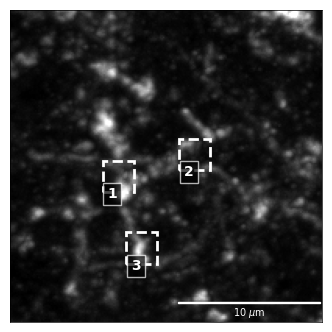

In [21]:
# Example: Create context panel showing where oligomer regions are located
# This shows ONE panel with the SAME zoom as quick_plotter, with THREE white boxes for oligomer regions
fig_context, axs_context = cell_oligomer_context_panel(
    file,
    oligomer_xmins=oligomers_xmins,  # The three oligomer box coordinates
    oligomer_xmaxs=oligomers_xmaxs,
    oligomer_ymins=oligomers_ymins,
    oligomer_ymaxs=oligomers_ymaxs,
    labelval=8,  # Same label as used in quick_plotter
    xmin=350,
    xmax=550,
    ymin=200,
    ymax=400,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
)
plt.tight_layout()
plt.savefig(
    os.path.join(folder_to_save, "Oligomers_Context_PD_Neurons.svg"),
    format="svg",
    dpi=1200,
)
plt.show(block=False)

In [ ]:
folder_to_save = r"C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith"
fig, axs = cell_oligomer_3panel_generator(
    filenames,
    cingulate_PD_data,
    folder_to_save,
    xmins=xmins,
    ymins=ymins,
    widths=widths,
    labelvals=labels,
)
plt.tight_layout()
plt.savefig(
    os.path.join(folder_to_save, "Example_neuronfigure.svg"), format="svg", dpi=1200
)